In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

data = pd.read_csv('/Dataset/FPT_1m_020124150526.csv')

In [102]:
from sklearn.model_selection import train_test_split

data = data.sort_values('time')

X = data.drop(columns=['time'])
y = data['close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.25, shuffle=False)

In [103]:
# create pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, StandardScaler

from sklearn import set_config
set_config(transform_output='pandas', display='diagram')

standardise = ColumnTransformer(
    transformers=
    [
        ("robust_scaler", RobustScaler(), ['volume']),
        ('standard_scaler', StandardScaler(), ['open', 'high', 'low', 'close'])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False, # not containing the transformer name in columns of Dataframe
    force_int_remainder_cols=False
)

In [ ]:
import joblib
from sklearn import set_config
set_config(transform_output='pandas', display='diagram')

# Load
standardise = joblib.load('/Model/standardise_transformer-1.joblib')

In [105]:
from sklearn.compose import ColumnTransformer

def inverse_transform_columntransformer(column_transformer:ColumnTransformer, X_transformed:pd.DataFrame):
    """Inverse transform entire ColumnTransformer output back to original scale"""
    X_original = X_transformed.copy()
    list_of_features = list(column_transformer.get_feature_names_out())
    
    for name, transformer, columns in column_transformer.transformers_:
        if name != 'remainder' and transformer is not None:
            # Get the indices of these columns in the transformed data
            col_indices = [list_of_features.index(col) for col in columns]
            
            X_original.iloc[:, col_indices] = transformer.inverse_transform(X_transformed.iloc[:, col_indices])
    
    df_inversed = pd.DataFrame(X_original, columns=list_of_features, index=X_transformed.index)
    
    return df_inversed

# LSTM Inference

In [ ]:
import numpy
import torch
from Model.lstm import LSTMModel
import torch.nn as nn

path = "/Model/best_lstm_model-1.pth"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

state_dict = torch.load(path, map_location=device,) #  weights_only=False
state_dict.keys()

dict_keys(['model_state', 'model_class', 'model_args', 'optimizer_state', 'epochs'])

In [110]:
model = LSTMModel(**state_dict['model_args'])
model = nn.DataParallel(model)
model.to(device)

model.load_state_dict(state_dict['model_state']) # state_dict['model_state']

<All keys matched successfully>

In [ ]:
from numpy.lib.stride_tricks import sliding_window_view

# build class to predict stock price from LSTM
class LSTMInference:
    def __init__(self, model, device):
        self.model = model.to(device)
        self.device = device

    def create_sequences(self, X: pd.DataFrame, lag: int) -> np.ndarray:
        """
        Vectorized version to create time series sequences.
        """
        X_values = X.values  # shape: (n_samples, n_features)
        
        # Create sliding windows for features (X)
        X_windows = sliding_window_view(X_values, window_shape=lag, axis=0).transpose(0, 2, 1) # (n_sequences, timesteps, n_features)

        X_seq = X_windows
       
        return X_seq

    def forecast(self, stock_data_past_current:pd.DataFrame, timesteps:int=30):
        # Forecast stock price for next period using stock price from past periods and current period
        self.model.eval()
        with torch.no_grad():
            X_seq = self.create_sequences(stock_data_past_current, lag=timesteps) # (B, timesteps, features)
            X_seq = torch.tensor(X_seq, dtype=torch.float32)
            X_seq = X_seq.to(self.device)
    
            y_forecast = self.model(X_seq) # (B, 1)
            y_forecast = y_forecast.squeeze(1)
            
            return y_forecast.tolist()

In [112]:
test_data = pd.read_csv('/kaggle/input/datasets/thuyduc/stock-data-fpt/x_test_stock_fpt.csv').drop(columns=['Unnamed: 0'])
test_data.head()

,volume,open,high,low,close
0,-0.152542,-0.581731,-0.578842,-0.578757,-0.575854
1,0.711864,-0.581731,-0.572951,-0.578757,-0.575854
2,0.231638,-0.575838,-0.578842,-0.578757,-0.575854
3,0.141243,-0.581731,-0.578842,-0.578757,-0.581747
4,0.937853,-0.581731,-0.572951,-0.578757,-0.575854


In [113]:
y_test = pd.read_csv('/kaggle/input/datasets/thuyduc/stock-data-fpt/y_test_stock_fpt.csv').drop(columns=['Unnamed: 0'])
x_test = pd.read_csv('/kaggle/input/datasets/thuyduc/stock-data-fpt/x_test_stock_fpt.csv').drop(columns=['Unnamed: 0'])

In [114]:
# build class to automatically forecast stock price in next minute when new data appears in current minute
# this class includes all processes from take data, transform data, forecast stock price 
# and inverse_transform stock price into standard format

class AutomaticallyStockForecast:
    def __init__(self, model, device):
        """
        Args:
            model: core model used to forecast data
            stock_data_checkpoint: stock data from past periods, this data is used in timesteps to act
                as past information in time-series data. This stock data have been preprocessed already
        """
        
        self.model_inference = LSTMInference(model, device)
        self.preprocessor = standardise

    def realtime_forecast(self, num_forecasts:int, timesteps:int):
        index = 0
        past_periods = timesteps - 1
        forecast_values = []
        
        for _ in range(num_forecasts):
            stock_data_checkpoint = test_data[index:past_periods+index]
            new_single_stock_data = test_data[past_periods+index:past_periods+index+1]

            data_for_model = pd.concat([stock_data_checkpoint, new_single_stock_data], axis=0)
            stock_price_forecast = self.model_inference.forecast(data_for_model, timesteps)

            df_temp = pd.DataFrame(0, columns=self.preprocessor.get_feature_names_out(), index=new_single_stock_data.index + 1, dtype=float)
            df_temp['close'] = stock_price_forecast

            # df_temp = inverse_transform_columntransformer(self.preprocessor, df_temp)
            index = index + 1
            forecast_values.append(df_temp['close'].values[0])

        return forecast_values

In [141]:
rl_forecast = AutomaticallyStockForecast(model, device)
forecast_value = rl_forecast.realtime_forecast(30000, 30)

In [161]:
df_ = pd.DataFrame()
df_['forecast'] = forecast_value
df_['real'] = y_test[30:30030].reset_index(drop=True)
df_.reset_index(inplace=True)

In [160]:
r2_score(df_['real'], df_['forecast'])

0.9948466847151448

In [163]:
import math
import itertools
from typing import Literal
from matplotlib.ticker import FuncFormatter
from matplotlib.axes import Axes
from matplotlib.figure import Figure
import matplotlib.pyplot as plt
import seaborn as sns

class LinePlot:
    def __init__(self, df:pd.DataFrame):
        self.df = df

    @staticmethod
    def readable_numbers(x: float) -> str:
        """
        takes a large number and formats it into K,M to make it more readable

        Args
            x: float value to format

        Returns
            str: formatted string
        """
        if x >= 1e6:
            s = '{:1.2f}M'.format(x*1e-6)
        else:
            s = '{:1.2f}K'.format(x*1e-3)
        return s
    
    def set_locator(self, axes: Axes):
        """
        Format x, y ticklabels into more readable form

        Args
            axes: matplotlib axes to format x, y ticklabels
        """
        def is_number(x):
            x = x.replace('−', '-')
            try:
                float(x)
                return True
            except ValueError:
                return False
    
        x_ticklabels = [tick.get_text() for tick in axes.get_xticklabels()]
        y_ticklabels = [tick.get_text() for tick in axes.get_yticklabels()]
    
        formatter = FuncFormatter(lambda val, pos: self.readable_numbers(val))

        if is_number(x_ticklabels[0]) == True:
            axes.xaxis.set_major_formatter(formatter)
        if is_number(y_ticklabels[0]) == True:
            axes.yaxis.set_major_formatter(formatter)
    
    def single_plot(
        self,
        x_axis: str,
        y_axis: str,
        hue: str | None = None,
        style: str | None = None,
        size: str | None = None,
        kwarg: dict | None = None,
        readable_label: bool = False,
        ax: Axes = None
    ) -> Axes:
        """
        Draw a visually stunning and readable line plot.
    
        Args:
            x_axis: categorical or numeric column for X-axis
            y_axis: numeric column for Y-axis
            hue: column for line colors (group)
            style: column for line styles (e.g., dashed, dotted)
            size: column for line thickness variation
            kwarg: additional seaborn.lineplot arguments
            readable_label: whether to format axes tick labels into readable form
            ax: matplotlib Axes to draw plot on
        """
    
        if ax is None:
            ax = plt.gca()
            fig = ax.get_figure()
            fig.set_size_inches(10, 6)
        if kwarg is None:
            kwarg = {}

        if hue is not None:
            palette='viridis'
        else:
            palette=None
        # --- 🎨 Line Plot ---
        line = sns.lineplot(
            data=self.df,
            x=x_axis,
            y=y_axis,
            hue=hue,
            style=style,
            size=size,
            ax=ax,
            # marker="o",             # ✅ Add circle markers to each data point
            linewidth=2.2,          # ✅ Slightly thicker lines
            # markersize=4,           # ✅ Larger markers for visibility
            alpha=0.9,              # ✅ Soft transparency for overlapping lines
            palette=palette,      # ✅ Modern, readable color palette
            **kwarg
        )
    
        # --- 🎭 Title & Axis Labels ---
        ax.set_title(
            f"{y_axis} vs {x_axis}",
            fontsize=12,
            fontweight="regular",
            # fontname="Times New Roman",
            # pad=15
        )
        ax.set_xlabel(x_axis, fontsize=12, labelpad=5) # fontname="Times New Roman"
        ax.set_ylabel(y_axis, fontsize=12, labelpad=10) # fontname="Times New Roman"
    
        # --- 📏 Tick Formatting ---
        ax.tick_params(axis="x", rotation=0, labelsize=11)
        ax.tick_params(axis="y", rotation=0, labelsize=11)
        ax.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.5)
    
        # --- 🎨 Legend ---
        if hue or style or size:
            leg = ax.legend(
                title="Legend",
                title_fontsize=11,
                fontsize=10,
                loc="best",
                frameon=False,
                fancybox=True,
                framealpha=0.9,
            )
            leg.get_frame().set_linewidth(0.7)
            leg.get_frame().set_edgecolor("gray")
    
        # --- 📊 Optional: Format Large Axis Labels ---
        if readable_label:
            self.set_locator(ax)
    
        # --- 💅 Aesthetic Cleanup ---
        sns.despine(ax=ax, top=True, right=True)
    
        return line

    def multiple_plots(self, x_axis_list: list[str], y_axis_list: list[str], hue_list: list[str|None], 
                       kwarg: dict, plots_each_row: int, size_list: list[str|None], style_list: list[str|None],
                       readable_label: bool = False) -> (Figure, np.array([Axes])):
        """
        Draw multiple plots

        Args
            Same as single_plot
            y_axis_list: list of columns for y axis
            x_axis_list: list of columns for x axis
            hue_list
            size_list
            style_list
            plots_each_row: number of plots for each row in matplotlib figure
            kwarg: additional seaborn.lineplot arguments
        """
        
        combination = list(zip(x_axis_list, y_axis_list, hue_list, size_list, style_list))
        
        length = len(combination)
        number_rows = math.ceil(length / plots_each_row)
    
        fig, axes = plt.subplots(nrows=number_rows, ncols=plots_each_row, figsize=(16, 12),
                                sharey=True) # same y_axis scale
        axes = np.array(axes).reshape(number_rows, plots_each_row)
    
        coordinates = list(itertools.product(range(number_rows), range(plots_each_row)))
    
        for coor, com in zip(coordinates, combination):
            x, y, hue, size, style = com
            ax = axes[coor]
            self.single_plot(
                x_axis=x,
                y_axis=y,
                hue=hue,
                size=size,
                style=style,
                readable_label=readable_label,
                kwarg=kwarg,
                ax=ax
            )
    
        # hide any unused axes
        for coor in coordinates[length:]:
            fig.delaxes(axes[coor])

        return fig, axes

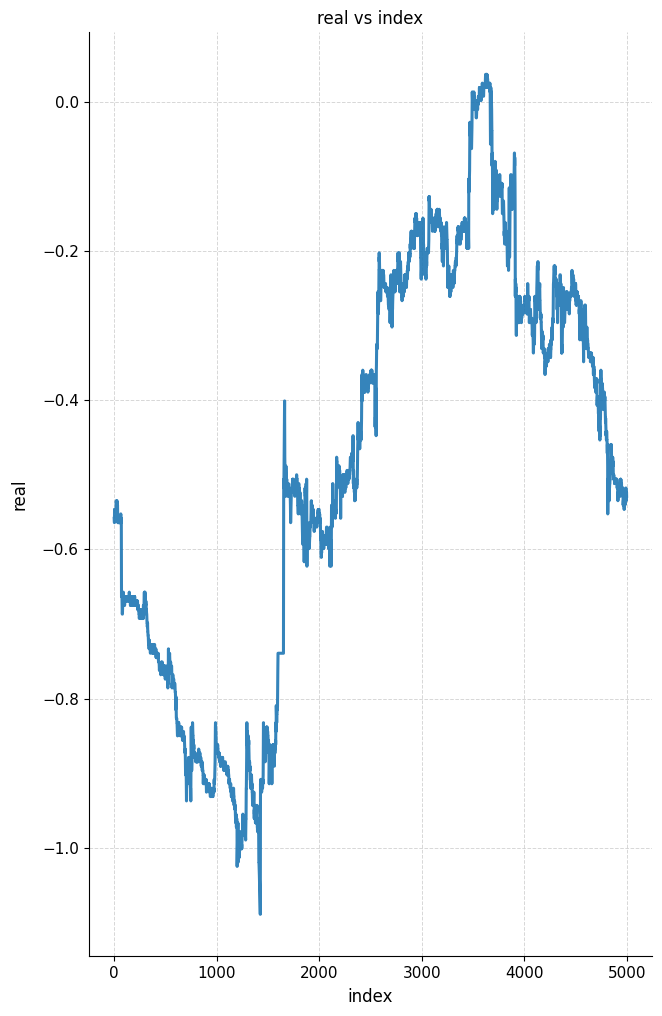

In [170]:
plotter = LinePlot(df_.iloc[:5000])

x_axis_list = ['index']
y_axis_list = ['real']
hue_list = [None for _ in range(1)]
style_list = [None for _ in range(1)]
size_list = [None for _ in range(1)]

fig, axes = plotter.multiple_plots(x_axis_list=x_axis_list, y_axis_list=y_axis_list, hue_list=hue_list,
                                      style_list=style_list, size_list=size_list, plots_each_row=2,
                                      kwarg={}, readable_label=False)

In [173]:
axes[0][0].plot(df_['index'].iloc[:5000], df_['forecast'].iloc[:5000])

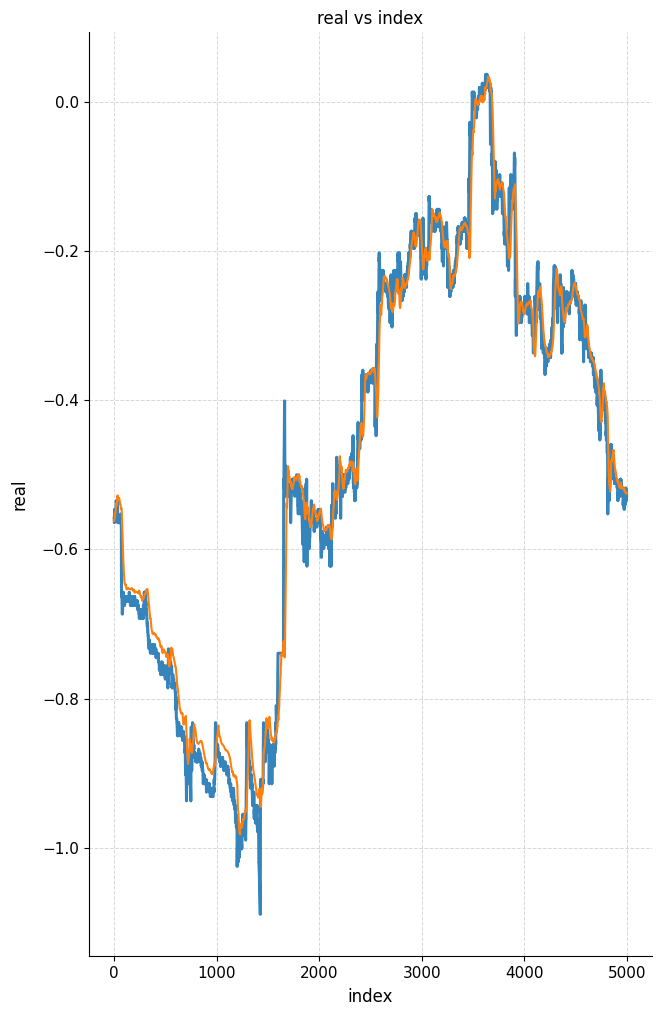

In [174]:
fig